# Replicating Boudraa et al. (2026): YOLO + MedSAM breast-lesion classification on BUSI

One notebook, top to bottom, on Kaggle. Every number in Tables 3 and 4 of the paper is produced here, printed next to the paper's own value and the difference.

**Paper.** Boudraa et al., *"Deep learning-based breast cancer detection in ultrasound images: Integration of YOLO, MedSAM, and Optuna hyperparameter optimization"*, Intelligence-Based Medicine 15 (2026) 100434.
**Claim.** yolov10b, tuned with Optuna and fused with MedSAM, classifies BUSI test images as benign / malignant / normal with accuracy **0.8803** (103/117), macro-F1 **0.8821**, malignant-F1 **0.8254**.

## The paper's pipeline

1. **Data.** BUSI: 780 ultrasound images (437 benign / 210 malignant / 133 normal), each lesion with a binary mask. Masks become bounding boxes; normal images get a full-image box. Stratified 70/15/15 split, seed 42; the training split is oversampled to 306 per class = 918 images.
2. **Detector.** 11 Ultralytics variants (YOLOv10 n/s/m/b/l/x, YOLO11 n/s/m/l/x) trained to detect the lesion box and its class.
3. **Hyperparameters.** Optuna (30 TPE trials × 50 epochs per variant) chose lr, momentum, weight decay, optimizer, image size, batch size. The winners are printed in Table 2, so we train with those values directly instead of re-running a >150-GPU-hour search.
4. **MedSAM.** Each predicted box prompts MedSAM, which returns a mask and a *predicted* IoU. Detector confidence × predicted IoU is the "fusion score".
5. **Image label.** The class of the best-scoring box (confidence in Configs A/B, confidence × IoU in C/D). Accuracy, F1, ROC-AUC on the 117 test images.

## What this notebook does

| step | what | leaves behind |
|---|---|---|
| 0 | settings, installs, resume from an earlier version | — |
| 1 | metric definitions, regression-tested against the paper's Fig. 6 confusion matrix | — |
| 2 | build the YOLO dataset: masks→boxes, near-duplicate scan, split, oversample | `results/manifest.csv`, `results/dedup_report.csv`, leakage figure |
| 3 | hyperparameters: Table 2 (Config B) vs Ultralytics stock (Config A) | `hparams.json` |
| 4 | train 14 runs (11 × B for Table 3, 3 × A for Table 4) + extra seeds, two at a time on the two T4s | `results/<run>/{preds.json, metrics.json, best.pt}` |
| 5 | MedSAM: embed the test images once, §4.3 oracle segmentation eval, score every run's boxes | `results/<run>/preds_fused.json`, `results/medsam_standalone.json` |
| 6 | Tables 3 & 4 with deltas, gates, seed variance, leakage-corrected table, figures | `report/` |

## Running it on Kaggle

1. **Add Input → Datasets** → *Breast Ultrasound Images Dataset* (`aryashah2k/breast-ultrasound-images-dataset`).
2. **Settings** → Accelerator **GPU T4 x2** · Internet **On** (pip + weight downloads).
3. Leave `SMOKE = True` and **Run All** once (~15 min). It exercises every cell on 3 tiny runs; if the last cell prints a report, the pipeline works end to end.
4. Set `SMOKE = False` → **Save Version → Save & Run All (Commit)**. Kaggle runs it in the background (close the browser if you like) and stores `/kaggle/working` as that version's output when it ends. Expect ≈ 7–8 h on 2×T4 (≈ 12 h on a single P100 — the budget below then leaves the tail for a second run).
5. Left-overs (time budget hit, a crash): **Add Input → Your Work → this notebook** (its output), run again. Runs that already have a `preds.json` are reused; only the missing ones train.

Kaggle hard-kills a session at 12 h **and discards its output**, which is why step 4 has a time budget and a hard stop: whatever finished is always saved.

In [1]:
# ───────────────────────────── settings ─────────────────────────────
SMOKE = False                 # True : 3 runs x 2 epochs, ~15 min, exercises every cell. Run this FIRST.
                             # False: the real thing, ~7-8 h on 2xT4. Smoke output goes to results_smoke/, real to results/.
SEED = 42                    # the paper's seed
BUDGET_MIN    = 10.0 * 60    # do not START a run expected to end after this many minutes since notebook start
HARD_STOP_MIN = 11.2 * 60    # kill whatever is still training at this point so the notebook ends (and saves) before Kaggle's 12 h cap
SEEDS_EXTRA   = [7, 1337]    # extra seeds for the headline variant; queued last, run only if time is left

In [2]:
# needs Settings -> Internet: On (pip + weight downloads). If this cell fails, the rest cannot run.
%pip install -q "ultralytics==8.3.40" "transformers>=4.44"

import os, sys, json, math, time, shutil, random, re, csv, subprocess
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd, cv2, torch
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
if not hasattr(np, "trapz"): np.trapz = np.trapezoid        # ultralytics 8.3.40 predates numpy 2.3, which dropped np.trapz
from IPython.display import display, Image as IPImage

ON_KAGGLE = Path("/kaggle/working").is_dir()
WORK  = Path("/kaggle/working") if ON_KAGGLE else Path("work").resolve()   # everything we produce
INPUT = Path("/kaggle/input")   if ON_KAGGLE else Path("input").resolve()  # BUSI + optional previous output
DATA, RUNS, WEIGHTS, CACHE, REPORT = (WORK / n for n in ("busi_yolo", "runs", "weights", "medsam_cache", "report"))
RESULTS = WORK / ("results_smoke" if SMOKE else "results")
for d in (DATA, RUNS, WEIGHTS, CACHE, REPORT, RESULTS):
    d.mkdir(parents=True, exist_ok=True)

CLASSES = ["benign", "malignant", "normal"]
CLS_ID  = {c: i for i, c in enumerate(CLASSES)}
T_START = time.time()
def elapsed_min(): return (time.time() - T_START) / 60

import ultralytics, transformers
N_GPU = torch.cuda.device_count()
print(f"python {sys.version.split()[0]} | torch {torch.__version__} | ultralytics {ultralytics.__version__} | transformers {transformers.__version__}")
print(f"GPUs: {[torch.cuda.get_device_name(i) for i in range(N_GPU)] or 'none (CPU)'}")
print(f"work dir {WORK} | results -> {RESULTS.name}/ | SMOKE={SMOKE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 39.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
python 3.12.13 | torch 2.10.0+cu128 | ultralytics 8.3.40 | transformers 5.0.0
GPUs: ['Tesla T4', 'Tesla T4']
work dir /kaggle/working | results -> results/ | SMOKE=False


### Resuming
Kaggle saves `/kaggle/working` only when a committed run finishes. If an earlier version of this notebook is attached as an input (*Add Input → Your Work*), every run folder that already contains a `preds.json` is copied over now and skipped by the scheduler in step 4.

In [3]:
reused = []
for p in INPUT.glob("*/results/*/preds.json"):
    dst = RESULTS / p.parent.name
    if not SMOKE and not (dst / "preds.json").exists():
        shutil.copytree(p.parent, dst, dirs_exist_ok=True); reused.append(dst.name)
print(f"reused {len(reused)} finished run(s) from attached inputs: {reused}" if reused
      else "no previous results attached - starting from scratch")

no previous results attached - starting from scratch


## Step 1 — What we are trying to hit, and how it is scored

The paper's headline (Table 3, yolov10b row) is Fig. 6's confusion matrix:

```
                 predicted
               ben   mal   nor
true  benign    57     6     3
      malignant  5    26     0
      normal     0     0    20        103/117 = 0.8803
```

**From detector to image label.** The paper never states how a set of box predictions becomes one label per image. The only reading consistent with its own Table 4 — where adding MedSAM leaves yolov10b's numbers *exactly* unchanged and makes yolov10n / yolo11s slightly *worse* — is:

* Config A/B: the image's label is the class of its **highest-confidence** box.
* Config C/D: the label is the class of the box with the highest **confidence × MedSAM-predicted-IoU**.
* No boxes at all → fall back to `normal`; the rate is reported (≈0 at a 0.001 confidence threshold).

Per-class scores for ROC-AUC are the best score of each class among the image's boxes. The 95 % CI is a 1000-sample bootstrap over test images. The cell below encodes all of this and checks it against Fig. 6 — it must reproduce 0.8803 / 0.8821 / 0.8254 exactly before anything is trained.

In [4]:
PAPER = {
    "headline": dict(acc=0.8803, f1_macro=0.8821, f1_malignant=0.8254, ci95=(0.8156, 0.9348)),
    "fig6_confusion": [[57, 6, 3], [5, 26, 0], [0, 0, 20]],
    # Table 3 (Config B, i.e. +Optuna, no MedSAM)
    "table3": {
        "yolov10n": dict(acc=0.8803, f1_macro=0.8713, f1_benign=0.9120, f1_malignant=0.8182, f1_normal=0.8837, map50=0.7830),
        "yolov10s": dict(acc=0.8547, f1_macro=0.8439, f1_benign=0.8871, f1_malignant=0.7937, f1_normal=0.8511, map50=0.7938),
        "yolov10m": dict(acc=0.8718, f1_macro=0.8554, f1_benign=0.9091, f1_malignant=0.8000, f1_normal=0.8571, map50=0.7883),
        "yolov10b": dict(acc=0.8803, f1_macro=0.8821, f1_benign=0.8906, f1_malignant=0.8254, f1_normal=0.9302, map50=0.8263),
        "yolov10l": dict(acc=0.8376, f1_macro=0.8281, f1_benign=0.8640, f1_malignant=0.7869, f1_normal=0.8333, map50=0.7926),
        "yolov10x": dict(acc=0.8547, f1_macro=0.8423, f1_benign=0.8871, f1_malignant=0.8065, f1_normal=0.8333, map50=0.7905),
        "yolo11n":  dict(acc=0.8376, f1_macro=0.8333, f1_benign=0.8661, f1_malignant=0.7500, f1_normal=0.8837, map50=0.8439),
        "yolo11s":  dict(acc=0.8632, f1_macro=0.8556, f1_benign=0.8837, f1_malignant=0.8136, f1_normal=0.8696, map50=0.8414),
        "yolo11m":  dict(acc=0.8462, f1_macro=0.8328, f1_benign=0.8788, f1_malignant=0.7500, f1_normal=0.8696, map50=0.8601),
        "yolo11l":  dict(acc=0.8718, f1_macro=0.8609, f1_benign=0.9008, f1_malignant=0.7931, f1_normal=0.8889, map50=0.8134),
        "yolo11x":  dict(acc=0.8462, f1_macro=0.8372, f1_benign=0.8769, f1_malignant=0.7458, f1_normal=0.8889, map50=0.8595),
    },
    # Table 4 ablation: A = YOLO only, B = +Optuna, C = +MedSAM, D = full pipeline
    "table4": {
        "yolov10b": dict(A=dict(acc=0.8462, f1_macro=0.8314, f1_malignant=0.7500), B=dict(acc=0.8803, f1_macro=0.8821, f1_malignant=0.8254),
                         C=dict(acc=0.8547, f1_macro=0.8409, f1_malignant=0.7719), D=dict(acc=0.8803, f1_macro=0.8821, f1_malignant=0.8254)),
        "yolov10n": dict(A=dict(acc=0.8205, f1_macro=0.8106, f1_malignant=0.7797), B=dict(acc=0.8803, f1_macro=0.8713, f1_malignant=0.8182),
                         C=dict(acc=0.8205, f1_macro=0.8106, f1_malignant=0.7797), D=dict(acc=0.8718, f1_macro=0.8617, f1_malignant=0.8182)),
        "yolo11s":  dict(A=dict(acc=0.8376, f1_macro=0.8164, f1_malignant=0.7797), B=dict(acc=0.8632, f1_macro=0.8556, f1_malignant=0.8136),
                         C=dict(acc=0.8376, f1_macro=0.8164, f1_malignant=0.7797), D=dict(acc=0.8547, f1_macro=0.8465, f1_malignant=0.8136)),
    },
    # Table 2: the validation mAP@0.5 Optuna's best trial reached for each variant
    "table2_val_map50": dict(yolov10n=0.7541, yolov10s=0.8262, yolov10m=0.8282, yolov10b=0.8518, yolov10l=0.8310, yolov10x=0.7818,
                             yolo11n=0.7885, yolo11s=0.8622, yolo11m=0.8401, yolo11l=0.8414, yolo11x=0.8209),
    # Section 4.3: MedSAM segmentation quality with ground-truth-box prompts
    "medsam_sec43": dict(benign=dict(dice=0.9396, iou=0.8879), malignant=dict(dice=0.9178, iou=0.8510), overall=dict(dice=0.9326, iou=0.876)),
}

FALLBACK = CLS_ID["normal"]   # image with zero boxes -> "normal"

def image_scores(rec, mode):
    "One image -> (per-class score vector, predicted label, had_any_box). mode = 'yolo' | 'fusion'."
    s = np.zeros(len(CLASSES))
    ious = rec.get("ious")
    for i, (c, conf) in enumerate(zip(rec["clss"], rec["confs"])):
        v = conf if mode == "yolo" else conf * (ious[i] if ious else 1.0)
        s[c] = max(s[c], v)
    if s.sum() == 0:
        s[FALLBACK] = 1e-9
        return s, FALLBACK, False
    return s, int(np.argmax(s)), True

def confusion(y, p, k=3):
    m = np.zeros((k, k), int)
    for a, b in zip(y, p): m[a, b] += 1
    return m

def prf(m):
    "Per-class precision / recall / F1 from a confusion matrix (rows = truth)."
    out = []
    for i in range(m.shape[0]):
        tp, col, row = m[i, i], m[:, i].sum(), m[i, :].sum()
        prec = tp / col if col else 0.0
        rec  = tp / row if row else 0.0
        out.append(dict(precision=prec, recall=rec, f1=2 * prec * rec / (prec + rec) if prec + rec else 0.0))
    return out

def auc_ovr(y, S, cls):
    "One-vs-rest ROC-AUC via the rank statistic (ties averaged). No sklearn needed."
    s = S[:, cls]; y = np.asarray(y)
    pos, neg = s[y == cls], s[y != cls]
    if len(pos) == 0 or len(neg) == 0: return float("nan")
    allv = np.concatenate([pos, neg]); order = np.argsort(allv, kind="mergesort")
    ranks = np.empty(len(allv)); ranks[order] = np.arange(1, len(allv) + 1)
    for v in np.unique(allv):
        idx = np.where(allv == v)[0]
        if len(idx) > 1: ranks[idx] = ranks[idx].mean()
    return float((ranks[:len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg)))

def evaluate(preds, mode, keep=None, n_boot=1000, seed=42):
    "preds: {stem: {true, boxes, confs, clss[, ious]}} -> image-level metrics. keep: optional subset of stems."
    stems = sorted(s for s in preds if keep is None or s in keep)
    y, p, S, had = [], [], [], []
    for st in stems:
        s, lab, hb = image_scores(preds[st], mode)
        y.append(preds[st]["true"]); p.append(lab); S.append(s); had.append(hb)
    y, p, S = np.array(y), np.array(p), np.vstack(S)
    m = confusion(y, p); per = prf(m)
    res = dict(mode=mode, n=len(y), n_no_detection=int(len(y) - sum(had)),
               accuracy=float((y == p).mean()), n_correct=int((y == p).sum()),
               f1_macro=float(np.mean([c["f1"] for c in per])), confusion=m.tolist(),
               per_class={CLASSES[i]: {k: float(v) for k, v in per[i].items()} for i in range(3)},
               auc={CLASSES[i]: auc_ovr(y, S, i) for i in range(3)})
    if n_boot:
        rng = np.random.default_rng(seed); b_acc, b_f1 = [], []
        for _ in range(n_boot):
            idx = rng.integers(0, len(y), len(y))
            b_acc.append((y[idx] == p[idx]).mean()); b_f1.append(np.mean([c["f1"] for c in prf(confusion(y[idx], p[idx]))]))
        res["acc_ci95"] = [float(np.percentile(b_acc, 2.5)), float(np.percentile(b_acc, 97.5))]
        res["f1_macro_ci95"] = [float(np.percentile(b_f1, 2.5)), float(np.percentile(b_f1, 97.5))]
    res["_arrays"] = (y, p, S)   # for the figures; stripped before anything is written to disk
    return res

# ---- regression test: rebuild Fig. 6 as fake predictions and demand the paper's own numbers back
cm = np.array(PAPER["fig6_confusion"]); fake = {}
for i in range(3):
    for j in range(3):
        for k in range(cm[i, j]):
            fake[f"img{len(fake)}"] = dict(true=i, boxes=[[0, 0, 1, 1]], confs=[1.0], clss=[j])
r = evaluate(fake, "yolo")
print(f"Fig. 6 -> acc {r['accuracy']:.4f}  F1 macro {r['f1_macro']:.4f}  F1 malignant {r['per_class']['malignant']['f1']:.4f}"
      f"  bootstrap CI95(acc) [{r['acc_ci95'][0]:.4f}, {r['acc_ci95'][1]:.4f}]   paper CI [0.8156, 0.9348]")
assert abs(r["accuracy"] - 0.8803) < 5e-5 and abs(r["f1_macro"] - 0.8821) < 5e-5 and abs(r["per_class"]["malignant"]["f1"] - 0.8254) < 5e-5
print("metric definitions reproduce the paper's Table 3 yolov10b row exactly")

Fig. 6 -> acc 0.8803  F1 macro 0.8821  F1 malignant 0.8254  bootstrap CI95(acc) [0.8205, 0.9318]   paper CI [0.8156, 0.9348]
metric definitions reproduce the paper's Table 3 yolov10b row exactly


## Step 2 — Build the dataset the way the paper describes it

* **Masks → boxes.** BUSI ships one binary mask per lesion (`benign (7)_mask.png`, occasionally `_mask_1.png` for a second lesion). Each external contour becomes one YOLO box. **Normal images have no lesion; the paper gives them a full-image box** so the detector can emit the `normal` class. That makes "normal" trivially detectable — it is why normal recall is 100 % in the paper — and it is kept because the replication has to.
* **Near-duplicate scan.** BUSI is known to contain the same scan several times (re-cropped screenshots). The paper does not check. A 64-bit perceptual hash flags pairs at Hamming ≤ 6; pairs straddling the test boundary are leakage.
* **Split.** "Stratified 70/15/15, seed 42" = two `train_test_split` calls (30 % off, then half of that). sklearn rounds the held-out size **up** (`ceil`); that is what yields the paper's 66/31/20 = 117 test images — `round` gives 116 and nothing would be comparable. **Gate 0:** the test split must be exactly 66/31/20. The *members* of our test set still differ from theirs (their shuffle is unknown), so ±1–3 images of noise on every number is expected.
* **Oversampling.** Train is topped up to 306 per class = 918 images with bbox-aware flips, ±15° rotation, brightness/contrast jitter and noise (§3.1). Val and test are never touched.

In [5]:
TARGET_PER_CLASS = 306      # section 3.1: 918 balanced training images
MIN_CONTOUR_AREA = 50       # ignore mask specks smaller than this (pixels)
DEDUP_HAMMING    = 6        # phash distance at or below which two images count as the same scan

def find_root(start):
    "Locate the folder holding benign/ malignant/ normal/ (Kaggle re-uploads nest BUSI differently)."
    if all((start / c).is_dir() for c in CLASSES): return start
    for d in sorted(p for p in start.rglob("*") if p.is_dir()):
        if all((d / c).is_dir() for c in CLASSES): return d
    raise SystemExit(f"no folder with {CLASSES} under {start} - is the BUSI dataset attached as an input?")

def discover(root):
    "{stem: {cls, img, masks[]}}"
    items = {}
    for cls in CLASSES:
        for p in sorted((root / cls).glob("*.png")):
            if "_mask" not in p.stem: items[p.stem] = dict(cls=cls, img=p, masks=[])
        for p in sorted((root / cls).glob("*_mask*.png")):
            base = re.sub(r"_mask(_\d+)?$", "", p.stem)
            if base in items: items[base]["masks"].append(p)
    return items

def boxes_from_masks(rec, w, h):
    "Contours -> normalised YOLO boxes (cid, cx, cy, bw, bh). Normal images: one full-image box."
    cid = CLS_ID[rec["cls"]]
    if rec["cls"] == "normal": return [(cid, 0.5, 0.5, 1.0, 1.0)]
    out = []
    for mp in rec["masks"]:
        m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if m is None: continue
        if m.shape[:2] != (h, w): m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        _, m = cv2.threshold(m, 127, 255, cv2.THRESH_BINARY)
        cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            if cv2.contourArea(c) < MIN_CONTOUR_AREA: continue
            x, y, bw, bh = cv2.boundingRect(c)
            out.append((cid, (x + bw / 2) / w, (y + bh / 2) / h, bw / w, bh / h))
    return out

def phash(img, size=16):
    "64-bit perceptual hash: 16x16 grey -> DCT -> top-left 8x8 vs median."
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    g = cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA).astype(np.float32)
    d = cv2.dct(g)[:8, :8]
    return "".join("1" if v > np.median(d[1:]) else "0" for v in d.flatten())

def hamming(a, b): return sum(x != y for x, y in zip(a, b))

def aug_once(img, boxes, rng):
    "Section 3.1 augmentation, box-aware. boxes are normalised (cid, cx, cy, w, h)."
    h, w = img.shape[:2]; out = img.copy(); bb = [list(b) for b in boxes]
    if rng.random() < 0.5:                                   # horizontal flip
        out = cv2.flip(out, 1)
        for b in bb: b[1] = 1.0 - b[1]
    if rng.random() < 0.5:                                   # vertical flip
        out = cv2.flip(out, 0)
        for b in bb: b[2] = 1.0 - b[2]
    ang = rng.uniform(-15, 15)                               # rotation, box = bounding box of the rotated box
    M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, 1.0)
    out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    for b in bb:
        cx, cy, bw, bh = b[1] * w, b[2] * h, b[3] * w, b[4] * h
        corners = np.array([[cx - bw / 2, cy - bh / 2], [cx + bw / 2, cy - bh / 2], [cx + bw / 2, cy + bh / 2], [cx - bw / 2, cy + bh / 2]])
        rot = np.hstack([corners, np.ones((4, 1))]) @ M.T
        x0, y0 = np.maximum(rot.min(0), 0); x1, y1 = np.minimum(rot.max(0), [w, h])
        b[1], b[2], b[3], b[4] = (x0 + x1) / 2 / w, (y0 + y1) / 2 / h, (x1 - x0) / w, (y1 - y0) / h
    out = cv2.convertScaleAbs(out, alpha=rng.uniform(0.85, 1.15), beta=rng.uniform(-20, 20))   # contrast / brightness
    if rng.random() < 0.5:                                   # gaussian noise
        out = np.clip(out.astype(np.float32) + rng.normal(0, rng.uniform(3, 10), out.shape), 0, 255).astype(np.uint8)
    return out, [b for b in bb if b[3] > 0.01 and b[4] > 0.01]

In [6]:
rng, nprng = random.Random(SEED), np.random.default_rng(SEED)
BUSI_ROOT = find_root(INPUT); print("BUSI root:", BUSI_ROOT)
items = discover(BUSI_ROOT)

# ---- read every image once: boxes + hash
recs = []
for stem, rec in items.items():
    img = cv2.imread(str(rec["img"]))
    if img is None:                                   print("  skip unreadable", stem); continue
    if rec["cls"] != "normal" and not rec["masks"]:   print("  skip, no mask", stem);   continue
    h, w = img.shape[:2]; boxes = boxes_from_masks(rec, w, h)
    if not boxes:                                     print("  skip, empty mask", stem); continue
    recs.append(dict(stem=stem, cls=rec["cls"], path=rec["img"], boxes=boxes, phash=phash(img), wh=(w, h)))
print(f"{len(recs)} images kept  " + "  ".join(f"{c}={sum(r['cls'] == c for r in recs)}" for c in CLASSES))
assert 700 < len(recs) < 820, "this is not standard BUSI (780 images)"

# ---- near-duplicate pairs
dup_rows, seen = [], []
for r in recs:
    for s in seen:
        d = hamming(r["phash"], s["phash"])
        if d <= DEDUP_HAMMING: dup_rows.append(dict(a=s["stem"], a_cls=s["cls"], b=r["stem"], b_cls=r["cls"], hamming=d))
    seen.append(r)
print(f"near-duplicate pairs (hamming <= {DEDUP_HAMMING}): {len(dup_rows)}  of which hamming 0: {sum(d['hamming'] == 0 for d in dup_rows)}")

# ---- stratified two-stage split with sklearn's ceil semantics
by_cls = defaultdict(list)
for r in recs: by_cls[r["cls"]].append(r)
split = {}
for c, rs in by_cls.items():
    rs = sorted(rs, key=lambda x: x["stem"]); rng.shuffle(rs)
    n = len(rs); n_temp = math.ceil(0.30 * n); n_train = n - n_temp; n_val = math.ceil(0.50 * n_temp)
    for i, r in enumerate(rs):
        split[r["stem"]] = "train" if i < n_train else "val" if i < n_train + n_val else "test"
counts = {s: {c: sum(1 for r in recs if split[r["stem"]] == s and r["cls"] == c) for c in CLASSES} for s in ("train", "val", "test")}
for s in counts: print(f"  {s:5s} " + "  ".join(f"{c}={n:3d}" for c, n in counts[s].items()) + f"  total={sum(counts[s].values())}")

# ---- Gate 0: Fig. 6 sums to 66/31/20
assert counts["test"] == dict(benign=66, malignant=31, normal=20), f"TEST SPLIT MISMATCH {counts['test']} - nothing downstream would be comparable"
print("Gate 0 passed: test split is 66/31/20 = 117, as in the paper")

# ---- write YOLO layout (wipe first so a rerun can never leave one image in two splits)
for s in ("train", "val", "test"):
    shutil.rmtree(DATA / s, ignore_errors=True)
    (DATA / s / "images").mkdir(parents=True); (DATA / s / "labels").mkdir(parents=True)
def write(stem, s, img, boxes):
    cv2.imwrite(str(DATA / s / "images" / f"{stem}.png"), img)
    (DATA / s / "labels" / f"{stem}.txt").write_text("".join(f"{cid} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n" for cid, cx, cy, bw, bh in boxes))
train_pool = defaultdict(list)
for r in recs:
    img = cv2.imread(str(r["path"])); write(r["stem"], split[r["stem"]], img, r["boxes"])
    if split[r["stem"]] == "train": train_pool[r["cls"]].append((r["stem"], img, r["boxes"]))

# ---- oversample train only, to 306 per class
for c, pool in train_pool.items():
    need = TARGET_PER_CLASS - len(pool); added = 0
    for i in range(max(need, 0)):
        stem, img, boxes = pool[i % len(pool)]
        a_img, a_box = aug_once(img, boxes, nprng)
        if a_box: write(f"{stem}__aug{i}", "train", a_img, a_box); added += 1
    print(f"  train {c:9s} {len(pool)} originals + {added} augmented = {len(pool) + added}")

(DATA / "data.yaml").write_text(f"path: {DATA}\ntrain: train/images\nval: val/images\ntest: test/images\nnc: 3\nnames: {CLASSES}\n")
pd.DataFrame([dict(stem=r["stem"], cls=r["cls"], split=split[r["stem"]], phash=r["phash"], w=r["wh"][0], h=r["wh"][1], n_boxes=len(r["boxes"])) for r in recs]).to_csv(RESULTS / "manifest.csv", index=False)
pd.DataFrame(dup_rows).to_csv(RESULTS / "dedup_report.csv", index=False)
n_img = {s: len(list((DATA / s / "images").glob("*.png"))) for s in ("train", "val", "test")}
print("images on disk:", n_img, "| data.yaml written")
assert n_img["val"] == 118 and n_img["test"] == 117

BUSI root: /kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
780 images kept  benign=437  malignant=210  normal=133
near-duplicate pairs (hamming <= 6): 202  of which hamming 0: 35
  train benign=305  malignant=147  normal= 93  total=545
  val   benign= 66  malignant= 32  normal= 20  total=118
  test  benign= 66  malignant= 31  normal= 20  total=117
Gate 0 passed: test split is 66/31/20 = 117, as in the paper
  train benign    305 originals + 1 augmented = 306
  train malignant 147 originals + 159 augmented = 306
  train normal    93 originals + 213 augmented = 306
images on disk: {'train': 918, 'val': 118, 'test': 117} | data.yaml written


### Leakage: how much of the test set has a twin in train/val?
Anything trained on `train` and early-stopped on `val` has effectively seen these test images. The set is saved so step 6 can score the clean and the contaminated part of the test set separately.

pairs straddling the test boundary: 51
test images with a near-duplicate in train or val: 43 / 117 = 37%  (benign=30  malignant=5  normal=8)
cross-class duplicate pairs (same scan, different label): 10
           a  a_cls               b     b_cls  hamming a_split b_split
benign (433) benign malignant (145) malignant        0     val     val
benign (131) benign  malignant (51) malignant        4     val   train
 benign (42) benign  malignant (51) malignant        2     val   train
benign (164) benign  malignant (52) malignant        4   train    test
 benign (85) benign  malignant (52) malignant        4    test    test
benign (333) benign  malignant (77) malignant        4     val   train
benign (399) benign  malignant (93) malignant        2    test    test
benign (406) benign  malignant (94) malignant        0   train   train
benign (269) benign      normal (1)    normal        4   train     val
benign (437) benign     normal (34)    normal        3   train    test


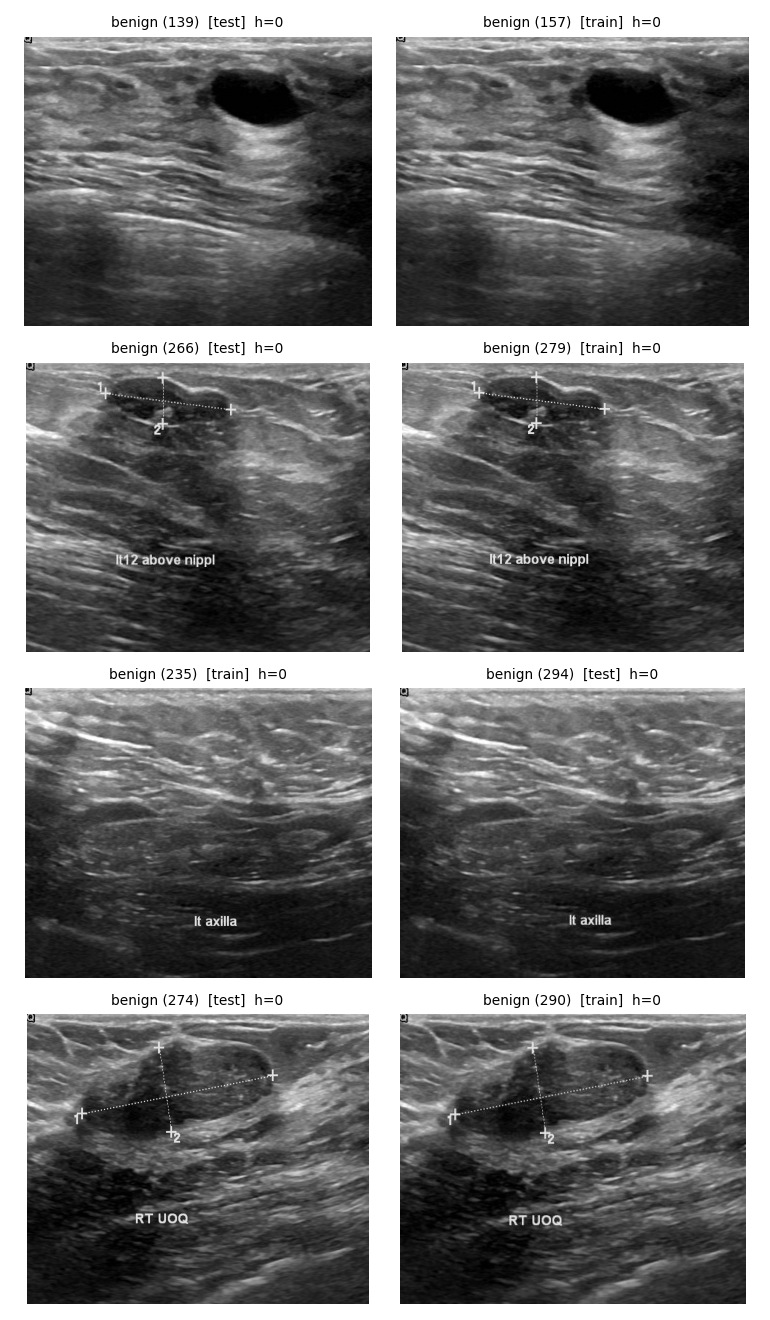

In [7]:
dup = pd.DataFrame(dup_rows); sp = {r["stem"]: split[r["stem"]] for r in recs}
dup["a_split"], dup["b_split"] = dup.a.map(sp), dup.b.map(sp)
straddle = dup[(dup.a_split != dup.b_split) & ((dup.a_split == "test") | (dup.b_split == "test"))]
LEAKY_TEST = sorted(set(straddle.a[straddle.a_split == "test"]) | set(straddle.b[straddle.b_split == "test"]))
cross = dup[dup.a_cls != dup.b_cls]
print(f"pairs straddling the test boundary: {len(straddle)}")
print(f"test images with a near-duplicate in train or val: {len(LEAKY_TEST)} / 117 = {len(LEAKY_TEST)/117:.0%}"
      + "  (" + "  ".join(f"{c}={sum(sp_c == c for sp_c in (next(r['cls'] for r in recs if r['stem']==s) for s in LEAKY_TEST))}" for c in CLASSES) + ")")
print(f"cross-class duplicate pairs (same scan, different label): {len(cross)}")
if len(cross): print(cross.to_string(index=False))
(RESULTS / "leaky_test_stems.json").write_text(json.dumps(LEAKY_TEST, indent=1))

# a few of the closest straddling pairs, side by side
show = straddle.sort_values("hamming").head(4)
fig, ax = plt.subplots(len(show), 2, figsize=(7, 3 * len(show)))
for k, (_, row) in enumerate(show.iterrows()):
    for j, (stem, spl) in enumerate([(row.a, row.a_split), (row.b, row.b_split)]):
        im = cv2.imread(str(items[stem]["img"]), cv2.IMREAD_GRAYSCALE)
        ax[k, j].imshow(im, cmap="gray"); ax[k, j].set_title(f"{stem}  [{spl}]  h={row.hamming}", fontsize=9); ax[k, j].axis("off")
plt.tight_layout(); plt.savefig(REPORT / "fig_leakage_pairs.png", dpi=110); plt.close()
display(IPImage(filename=str(REPORT / "fig_leakage_pairs.png")))

## Step 3 — Hyperparameters: Table 2 instead of a 150-GPU-hour Optuna search

The paper ran 30 TPE trials × 50 epochs for each of 11 variants (16,500 training epochs). Table 2 publishes what the search found, so training with those values reproduces every result; the search itself is only a claim about *where the numbers came from* and is not rerun.

* **Config A** ("YOLO only"): Ultralytics stock settings — SGD, lr 0.01, imgsz 640, batch 16.
* **Config B** ("+Optuna"): Table 2 values, verbatim. yolov10l's `imgsz=416` lies outside the search space §3.3 claims ({512, 640, 800}); a defect in the paper, carried as-is because Table 2 is what produced Table 3.
* Both configs share the §3.4 augmentation, 200 epochs, early-stopping patience 30, seed 42.
* **Configs C and D** are A and B re-scored with the MedSAM fusion — no extra training.

In [8]:
COMMON = dict(epochs=200, patience=30, warmup_epochs=3, cos_lr=False, cache="ram", workers=2, deterministic=True,
              # section 3.4 augmentation
              fliplr=0.5, flipud=0.5, mosaic=1.0, mixup=0.1, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, degrees=15.0, scale=0.5, perspective=0.0005)
CONFIG_A = dict(lr0=0.01, momentum=0.937, weight_decay=0.0005, optimizer="SGD", imgsz=640, batch=16)
TABLE2 = {   # Boudraa et al. Table 2, verbatim
    "yolov10n": dict(lr0=8.165e-04, momentum=0.7214, weight_decay=0.007325,  optimizer="AdamW", imgsz=640, batch=8),
    "yolov10s": dict(lr0=4.844e-03, momentum=0.6548, weight_decay=0.001440,  optimizer="SGD",   imgsz=640, batch=8),
    "yolov10m": dict(lr0=1.200e-05, momentum=0.6515, weight_decay=3.227e-05, optimizer="AdamW", imgsz=512, batch=16),
    "yolov10b": dict(lr0=7.372e-05, momentum=0.6657, weight_decay=0.000686,  optimizer="Adam",  imgsz=640, batch=8),
    "yolov10l": dict(lr0=6.751e-05, momentum=0.6826, weight_decay=0.000281,  optimizer="Adam",  imgsz=416, batch=16),
    "yolov10x": dict(lr0=2.178e-04, momentum=0.6555, weight_decay=0.000694,  optimizer="AdamW", imgsz=512, batch=4),
    "yolo11n":  dict(lr0=3.508e-04, momentum=0.8645, weight_decay=2.089e-05, optimizer="AdamW", imgsz=512, batch=4),
    "yolo11s":  dict(lr0=1.352e-04, momentum=0.6451, weight_decay=1.031e-05, optimizer="Adam",  imgsz=512, batch=16),
    "yolo11m":  dict(lr0=1.069e-04, momentum=0.7743, weight_decay=5.016e-06, optimizer="Adam",  imgsz=640, batch=16),
    "yolo11l":  dict(lr0=8.471e-03, momentum=0.7070, weight_decay=0.000190,  optimizer="SGD",   imgsz=640, batch=16),
    "yolo11x":  dict(lr0=2.667e-03, momentum=0.8046, weight_decay=0.000327,  optimizer="SGD",   imgsz=640, batch=4),
}
VARIANTS = list(TABLE2)
HP_JSON = WORK / "hparams.json"
HP_JSON.write_text(json.dumps(dict(common=COMMON, config_A=CONFIG_A, table2=TABLE2), indent=1))
display(pd.DataFrame(TABLE2).T.assign(paper_val_mAP50=pd.Series(PAPER["table2_val_map50"])))

,lr0,momentum,weight_decay,optimizer,imgsz,batch,paper_val_mAP50
yolov10n,0.000816,0.7214,0.007325,AdamW,640,8,0.7541
yolov10s,0.004844,0.6548,0.00144,SGD,640,8,0.8262
yolov10m,0.000012,0.6515,0.000032,AdamW,512,16,0.8282
yolov10b,0.000074,0.6657,0.000686,Adam,640,8,0.8518
yolov10l,0.000068,0.6826,0.000281,Adam,416,16,0.8310
yolov10x,0.000218,0.6555,0.000694,AdamW,512,4,0.7818
yolo11n,0.000351,0.8645,0.000021,AdamW,512,4,0.7885
yolo11s,0.000135,0.6451,0.00001,Adam,512,16,0.8622
yolo11m,0.000107,0.7743,0.000005,Adam,640,16,0.8401
yolo11l,0.008471,0.707,0.00019,SGD,640,16,0.8414


## Step 4 — Train

14 runs: 11 variants × Config B (Table 3) + the three ablation variants × Config A (Table 4), then two extra seeds of the headline variant if time is left. Each run is one subprocess of `train_worker.py` (written out below so it is visible exactly what a run does), pinned to one GPU; the scheduler keeps both T4s busy and prints one status line every few minutes instead of 14 progress bars.

Every run leaves `results/<variant>_<config>/`:
* `preds.json` — every box (xyxy, confidence, class) on every test image, at confidence ≥ 0.001 so the class-score vectors for AUC are complete. **This file is the contract**: everything after this step reads it and nothing after this step touches a `.pt`.
* `metrics.json` — hyperparameters actually used, epochs run, best epoch, val/test mAP.
* `best.pt`, `results.csv` (per-epoch curves), `train.log`.

Order matters because the session can die: headline variant first, then the rest of Table 4, then Table 3 longest-first (so the two GPUs finish together), then seeds.

In [9]:
# ---- Gate 1: every checkpoint downloads and loads under this Ultralytics version
from ultralytics import YOLO
WEIGHTS.mkdir(exist_ok=True)
for v in VARIANTS:
    YOLO(str(WEIGHTS / f"{v}.pt"))          # downloads into WEIGHTS/ on first call
print("Gate 1 passed:", ", ".join(f"{p.name} {p.stat().st_size/1e6:.0f}MB" for p in sorted(WEIGHTS.glob("*.pt"))))

100%|██████████| 5.59M/5.59M [00:00<00:00, 140MB/s]


100%|██████████| 15.9M/15.9M [00:00<00:00, 188MB/s]


100%|██████████| 32.1M/32.1M [00:00<00:00, 272MB/s]


100%|██████████| 39.7M/39.7M [00:00<00:00, 238MB/s]


100%|██████████| 50.0M/50.0M [00:00<00:00, 238MB/s]


...


100%|██████████| 18.4M/18.4M [00:00<00:00, 222MB/s]


100%|██████████| 38.8M/38.8M [00:00<00:00, 203MB/s]


100%|██████████| 49.0M/49.0M [00:00<00:00, 265MB/s]


100%|██████████| 109M/109M [00:00<00:00, 239MB/s] 


Gate 1 passed: yolo11l.pt 51MB, yolo11m.pt 41MB, yolo11n.pt 6MB, yolo11s.pt 19MB, yolo11x.pt 115MB, yolov10b.pt 42MB, yolov10l.pt 52MB, yolov10m.pt 34MB, yolov10n.pt 6MB, yolov10s.pt 17MB, yolov10x.pt 64MB


In [10]:
%%writefile train_worker.py
# One training run = one variant x one config x one seed.
# Writes <results>/<tag>/{preds.json, metrics.json, best.pt, results.csv}. Launched by the scheduler, one process per GPU.
import argparse, json, time, shutil, sys
from pathlib import Path

ap = argparse.ArgumentParser()
ap.add_argument("--variant", required=True); ap.add_argument("--config", required=True, choices=["A", "B"])
ap.add_argument("--seed", type=int, default=42)
ap.add_argument("--hp", type=Path, required=True); ap.add_argument("--data", type=Path, required=True)
ap.add_argument("--results", type=Path, required=True); ap.add_argument("--runs", type=Path, required=True)
ap.add_argument("--weights", type=Path, required=True)
ap.add_argument("--override", action="append", default=[], help="key=value train kwarg (smoke test: epochs=2)")
a = ap.parse_args()

cfg = json.loads(a.hp.read_text())
hp = dict(cfg["common"]); hp.update(cfg["config_A"] if a.config == "A" else cfg["table2"][a.variant]); hp["seed"] = a.seed
for kv in a.override:
    k, v = kv.split("=", 1)
    try: hp[k] = json.loads(v)
    except ValueError: hp[k] = v
tag = f"{a.variant}_{a.config}" + (f"_s{a.seed}" if a.seed != 42 else "")
out = a.results / tag; out.mkdir(parents=True, exist_ok=True)
print(f"[{tag}] hp = {json.dumps(hp)}", flush=True)

import torch, pandas as pd, numpy as np
if not hasattr(np, "trapz"): np.trapz = np.trapezoid        # ultralytics 8.3.40 predates numpy 2.3
from ultralytics import YOLO
from ultralytics.utils.callbacks import raytune as _raytune; _raytune.callbacks = {}   # Kaggle ships a newer ray than 8.3.40's tune hook expects; we never use it
hp.setdefault("device", 0 if torch.cuda.is_available() else "cpu")
data = str(a.data / "data.yaml")

t0 = time.time()
model = YOLO(str(a.weights / f"{a.variant}.pt"))
model.train(data=data, project=str(a.runs), name=tag, exist_ok=True, plots=False, val=True, verbose=False, **hp)
train_min = (time.time() - t0) / 60
save_dir = Path(model.trainer.save_dir); best = save_dir / "weights" / "best.pt"
rc = pd.read_csv(save_dir / "results.csv"); rc.columns = [c.strip() for c in rc.columns]
fitness = 0.1 * rc["metrics/mAP50(B)"] + 0.9 * rc["metrics/mAP50-95(B)"]     # what Ultralytics picks best.pt by
epochs_run, best_epoch = len(rc), int(rc.loc[fitness.idxmax(), "epoch"])

# ---- detection metrics on val (comparable to Table 2's objective) and on the held-out test split
m = YOLO(str(best))
val  = m.val(data=data, split="val",  imgsz=hp["imgsz"], batch=hp["batch"], device=hp["device"], plots=False, verbose=False)
test = m.val(data=data, split="test", imgsz=hp["imgsz"], batch=hp["batch"], device=hp["device"], plots=False, verbose=False)

# ---- every box on every test image -> preds.json (the contract for everything downstream)
preds, n_empty = {}, 0
for p in sorted((a.data / "test" / "images").glob("*.png")):
    r = m.predict(str(p), conf=0.001, iou=0.7, imgsz=hp["imgsz"], max_det=300, device=hp["device"], verbose=False)[0]
    boxes = r.boxes.xyxy.cpu().numpy().round(2).tolist()
    if not boxes: n_empty += 1
    preds[p.stem] = dict(true=int((a.data / "test" / "labels" / f"{p.stem}.txt").read_text().split()[0]),
                         boxes=boxes, confs=r.boxes.conf.cpu().numpy().round(5).tolist(), clss=[int(c) for c in r.boxes.cls.cpu().numpy()])
(out / "preds.json").write_text(json.dumps(dict(tag=tag, split="test", conf_thr=0.001, n_images=len(preds), n_empty=n_empty, preds=preds)))

metrics = dict(tag=tag, variant=a.variant, config=a.config, seed=a.seed, hp=hp, train_min=round(train_min, 1),
               epochs_run=epochs_run, best_epoch=best_epoch,
               val_map50=float(val.box.map50), val_map5095=float(val.box.map), test_map50=float(test.box.map50), test_map5095=float(test.box.map))
(out / "metrics.json").write_text(json.dumps(metrics, indent=1))
shutil.copy2(best, out / "best.pt"); shutil.copy2(save_dir / "results.csv", out / "results.csv")
print(f"[{tag}] DONE {json.dumps(metrics)}", flush=True)

Writing train_worker.py


In [11]:
# ---- the queue, in the order that survives an early death of the session
EST_MIN = dict(yolov10n=25, yolov10s=30, yolov10m=45, yolov10b=65, yolov10l=70, yolov10x=110,     # rough T4 minutes incl. early stop;
               yolo11n=22, yolo11s=25, yolo11m=45, yolo11l=60, yolo11x=105)                       # used only for budgeting
ABLATION = ["yolov10b", "yolov10n", "yolo11s"]                                                    # Table 4 variants

def job(variant, config, seed=42):
    return dict(tag=f"{variant}_{config}" + (f"_s{seed}" if seed != 42 else ""), variant=variant, config=config, seed=seed, est_min=EST_MIN[variant])

queue  = [job(v, c) for v in ABLATION for c in ("B", "A")]                                        # 1. everything Table 4 needs, headline first
queue += [job(v, "B") for v in sorted((v for v in VARIANTS if v not in ABLATION), key=lambda v: -EST_MIN[v])]   # 2. rest of Table 3, longest first
queue += [job("yolov10b", "B", s) for s in SEEDS_EXTRA]                                           # 3. seed variance on the headline
if SMOKE: queue = [job("yolov10n", "A"), job("yolov10n", "B"), job("yolo11n", "B")]               # one full Table 4 row + one Table 3 row
OVERRIDES = ["epochs=2"] if SMOKE else []
OVERRIDES += os.environ.get("BUSI_TEST_OVERRIDES", "").split()                                    # local CPU test only

done_before = [j["tag"] for j in queue if (RESULTS / j["tag"] / "preds.json").exists()]
queue = [j for j in queue if j["tag"] not in done_before]
print(f"{len(queue)} run(s) to train, ~{sum(j['est_min'] for j in queue)} T4-minutes: {[j['tag'] for j in queue]}")
if done_before: print(f"already finished (reused): {done_before}")

16 run(s) to train, ~847 T4-minutes: ['yolov10b_B', 'yolov10b_A', 'yolov10n_B', 'yolov10n_A', 'yolo11s_B', 'yolo11s_A', 'yolov10x_B', 'yolo11x_B', 'yolov10l_B', 'yolo11l_B', 'yolov10m_B', 'yolo11m_B', 'yolov10s_B', 'yolo11n_B', 'yolov10b_B_s7', 'yolov10b_B_s1337']


In [12]:
WORKER = Path("train_worker.py").resolve()
N_WORKERS = max(1, N_GPU)
STATUS_EVERY_S = 300

def run_queue(jobs):
    pending, running, finished, failed, unscheduled = list(jobs), {}, [], [], []
    free, last_status = list(range(N_WORKERS)), 0.0

    def launch(j, gpu):
        out = RESULTS / j["tag"]; out.mkdir(exist_ok=True)
        log = open(out / "train.log", "w")
        cmd = [sys.executable, str(WORKER), "--variant", j["variant"], "--config", j["config"], "--seed", str(j["seed"]),
               "--hp", str(HP_JSON), "--data", str(DATA), "--results", str(RESULTS), "--runs", str(RUNS), "--weights", str(WEIGHTS)]
        for kv in OVERRIDES: cmd += ["--override", kv]
        env = dict(os.environ, CUDA_VISIBLE_DEVICES=str(gpu), YOLO_VERBOSE="False")
        running[gpu] = dict(job=j, proc=subprocess.Popen(cmd, stdout=log, stderr=subprocess.STDOUT, env=env, cwd=str(WEIGHTS)), t0=time.time(), log=log)
        print(f"[{elapsed_min():6.1f} min] > {j['tag']} started on GPU{gpu}", flush=True)

    def epoch_of(tag):
        try: return sum(1 for _ in open(RUNS / tag / "results.csv")) - 1
        except OSError: return 0

    while pending or running:
        while free and pending:                                    # launch whatever fits the budget
            fits = [j for j in pending if SMOKE or elapsed_min() + 1.3 * j["est_min"] <= BUDGET_MIN]
            if not fits: break
            j = fits[0]; pending.remove(j); launch(j, free.pop(0))
        if free and pending and not running:                       # nothing fits and nothing is running: stop here
            unscheduled, pending = pending, []; break
        for gpu, r in list(running.items()):
            rc = r["proc"].poll()
            if rc is None and elapsed_min() > HARD_STOP_MIN:
                r["proc"].kill(); rc = -9; print(f"[{elapsed_min():6.1f} min] HARD STOP: killed {r['job']['tag']} to end before Kaggle's 12 h cap", flush=True)
            if rc is None: continue
            r["log"].close(); del running[gpu]; free.append(gpu)
            tag, mins = r["job"]["tag"], (time.time() - r["t0"]) / 60
            if (RESULTS / tag / "preds.json").exists():
                mj = json.loads((RESULTS / tag / "metrics.json").read_text())
                q = evaluate(json.loads((RESULTS / tag / "preds.json").read_text())["preds"], "yolo", n_boot=0)
                print(f"[{elapsed_min():6.1f} min] OK {tag}: {mins:.0f} min, {mj['epochs_run']} epochs (best {mj['best_epoch']}), "
                      f"test mAP50 {mj['test_map50']:.3f}, acc {q['accuracy']:.4f}, F1 {q['f1_macro']:.4f}", flush=True)
                finished.append(tag)
            else:
                tail = "".join(open(RESULTS / tag / "train.log", errors="ignore").readlines()[-12:])
                print(f"[{elapsed_min():6.1f} min] FAILED {tag} (rc={rc}) after {mins:.0f} min. Last log lines:\n{tail}", flush=True)
                failed.append(tag)
        if running and time.time() - last_status > STATUS_EVERY_S:
            last_status = time.time()
            print(f"[{elapsed_min():6.1f} min] running: " + ", ".join(f"{r['job']['tag']} @ epoch {epoch_of(r['job']['tag'])}" for r in running.values())
                  + f" | {len(pending)} pending", flush=True)
        time.sleep(10)
    return finished, failed, unscheduled

finished, failed, unscheduled = run_queue(queue)
print(f"\ntraining finished at {elapsed_min():.0f} min: {len(finished)} ok, {len(failed)} failed, {len(unscheduled)} not started")
if failed:      print("FAILED (see results/<tag>/train.log):", failed)
if unscheduled: print("NOT STARTED (time budget) - attach this version's output as an input and run again:", [j["tag"] for j in unscheduled])

[   1.2 min] > yolov10b_B started on GPU0
[   1.2 min] > yolov10b_A started on GPU1
[   1.2 min] running: yolov10b_B @ epoch 0, yolov10b_A @ epoch 0 | 14 pending
[   6.2 min] running: yolov10b_B @ epoch 4, yolov10b_A @ epoch 4 | 14 pending
[  11.2 min] running: yolov10b_B @ epoch 10, yolov10b_A @ epoch 11 | 14 pending
[  16.2 min] running: yolov10b_B @ epoch 16, yolov10b_A @ epoch 18 | 14 pending
[  21.2 min] running: yolov10b_B @ epoch 22, yolov10b_A @ epoch 25 | 14 pending
[  26.2 min] running: yolov10b_B @ epoch 28, yolov10b_A @ epoch 31 | 14 pending
[  31.2 min] running: yolov10b_B @ epoch 34, yolov10b_A @ epoch 38 | 14 pending
[  36.2 min] running: yolov10b_B @ epoch 40, yolov10b_A @ epoch 45 | 14 pending
[  41.2 min] running: yolov10b_B @ epoch 47, yolov10b_A @ epoch 51 | 14 pending
[  46.2 min] running: yolov10b_B @ epoch 53, yolov10b_A @ epoch 58 | 14 pending
[  51.2 min] running: yolov10b_B @ epoch 59, yolov10b_A @ epoch 65 | 14 pending
[  56.2 min] running: yolov10b_B @ epoch

## Step 5 — MedSAM

MedSAM is SAM (ViT-B) fine-tuned on medical images and prompted with a box. Per box it returns a mask and the decoder's *predicted* IoU — its own estimate of mask quality.

**The paper uses the word "IoU" for two different quantities.** §4.3 reports *true* IoU/Dice against ground-truth masks (Dice 0.9396). The fusion score `confidence × IoU` can only use the *predicted-IoU head*, because at test time there is no ground truth — and Fig. 3 shows "IoU=0.7698 | Dice=0.0000" on a normal image, impossible for a true IoU. Both are computed here and kept apart as `iou_true` and `iou_pred_head`.

**Preprocessing is not a detail here.** Two sources disagree on how an image must be fed to MedSAM:

| | geometry | normalisation |
|---|---|---|
| official `MedSAM_Inference.py` | squash to 1024×1024 | per-image min-max to [0, 1] |
| the HF checkpoint's `SamProcessor` config | longest edge 1024 + zero pad | ÷255, ImageNet mean/std |

Crossing the two axes gives four recipes. On 20 test images with ground-truth-box prompts they scored Dice 0.76 (official), 0.81 (HF), **0.91 (squash + ImageNet)**, 0.78 (pad + min-max) — a spread larger than any effect the paper reports, and only the best of them gets near the paper's 0.94. Cell (b) therefore runs §4.3 for all four and prints a sensitivity table; `choose_recipe()` decides which one the fusion uses.

The image encoder is the expensive part and does not depend on the box, so each test image is embedded once per recipe and cached; scoring the boxes of any run is decoder-only and takes seconds.

Three cells: **(a)** the model + preprocessing recipes · **(b)** §4.3 oracle eval — prompt with the *ground-truth* box, score the mask against the ground-truth mask, all four recipes · **(c)** score every box of every run with the chosen recipe → `preds_fused.json`.

In [13]:
from transformers import SamModel
import torch.nn.functional as F
IMAGENET_MEAN, IMAGENET_STD = np.array([0.485, 0.456, 0.406], np.float32), np.array([0.229, 0.224, 0.225], np.float32)
RECIPES = {"official (squash + min-max)": ("squash", "minmax"),   # MedSAM_Inference.py
           "HF SamProcessor (pad + ImageNet)": ("pad", "imagenet"),   # wanglab/medsam-vit-base preprocessor_config.json
           "squash + ImageNet": ("squash", "imagenet"),
           "pad + min-max": ("pad", "minmax")}

class MedSAM:
    MODEL_ID = "wanglab/medsam-vit-base"          # the official MedSAM ViT-B checkpoint, HF port
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = SamModel.from_pretrained(self.MODEL_ID).to(self.device).eval()

    @staticmethod
    def frame(H, W, geom):
        "How original pixels map into the 1024x1024 input: (sx, sy) box scale and (nh, nw) valid region."
        if geom == "squash": return 1024 / W, 1024 / H, 1024, 1024
        s = 1024 / max(H, W); return s, s, round(H * s), round(W * s)

    @classmethod
    def preprocess(cls, img_bgr, geom, norm):
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB); H, W = rgb.shape[:2]; sx, sy, nh, nw = cls.frame(H, W, geom)
        if geom == "squash": x = cv2.resize(rgb, (1024, 1024), interpolation=cv2.INTER_CUBIC).astype(np.float32)
        else: x = np.zeros((1024, 1024, 3), np.float32); x[:nh, :nw] = cv2.resize(rgb, (nw, nh), interpolation=cv2.INTER_LINEAR)
        x = (x - x.min()) / max(x.max() - x.min(), 1e-8) if norm == "minmax" else (x / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
        return torch.from_numpy(x).permute(2, 0, 1)[None]

    @torch.no_grad()
    def embed(self, img_bgr, geom, norm):
        return self.model.get_image_embeddings(self.preprocess(img_bgr, geom, norm).to(self.device))     # (1, 256, 64, 64)

    @torch.no_grad()
    def decode(self, emb, boxes_xyxy, hw, geom, want_masks=False, chunk=64):
        "boxes in original pixel coords -> (predicted-IoU per box, optional boolean masks (n,H,W) at original size)."
        H, W = hw; sx, sy, nh, nw = self.frame(H, W, geom)
        b = np.asarray(boxes_xyxy, np.float32).reshape(-1, 4) * np.array([sx, sy, sx, sy], np.float32)      # to the 1024 frame
        ious, masks = [], []
        for i in range(0, len(b), chunk):
            out = self.model(image_embeddings=emb, input_boxes=torch.from_numpy(b[i:i + chunk])[None].to(self.device), multimask_output=False)
            ious += out.iou_scores.reshape(-1).cpu().tolist()
            if want_masks:                                     # official: sigmoid -> resize to (H, W) -> > 0.5
                prob = torch.sigmoid(out.pred_masks[0, :, 0])[None]                              # (1, n, 256, 256)
                if geom == "pad": prob = F.interpolate(prob, size=(1024, 1024), mode="bilinear", align_corners=False)[..., :nh, :nw]
                masks.append((F.interpolate(prob, size=(H, W), mode="bilinear", align_corners=False)[0] > 0.5).cpu().numpy())
        return ious, (np.concatenate(masks) if want_masks else None)

medsam = MedSAM()
TEST_IMGS = sorted((DATA / "test" / "images").glob("*.png"))
TEST_IMGS = TEST_IMGS[:int(os.environ.get("BUSI_TEST_LIMIT", 0)) or None]      # local CPU test only
HW = {p.stem: cv2.imread(str(p)).shape[:2] for p in TEST_IMGS}
def get_emb(stem, geom, norm):
    "Embedding of a test image under one recipe, computed once and cached as fp16."
    f = CACHE / f"{stem}__{geom}_{norm}.npy"
    if not f.exists(): np.save(f, medsam.embed(cv2.imread(str(DATA / "test" / "images" / f"{stem}.png")), geom, norm).cpu().numpy().astype(np.float16))
    return torch.from_numpy(np.load(f)).float().to(medsam.device)
print(f"(a) MedSAM loaded on {medsam.device}; {len(HW)} test images")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/315 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared_image_embedding.positional_embedding to prompt_encoder.shared_embedding.positional_embedding, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

(a) MedSAM loaded on cuda; 117 test images


In [14]:
# (b) section 4.3: prompt with the ground-truth box, compare the mask with the ground-truth mask. Normal images have no mask and are excluded, as in the paper.
def gt_boxes_and_mask(stem):
    H, W = HW[stem]
    boxes = [[(cx - bw / 2) * W, (cy - bh / 2) * H, (cx + bw / 2) * W, (cy + bh / 2) * H]
             for _, cx, cy, bw, bh in (map(float, l.split()) for l in (DATA / "test" / "labels" / f"{stem}.txt").read_text().splitlines())]
    gt = np.zeros((H, W), bool)
    for mp in items[stem]["masks"]:
        g = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        gt |= (cv2.resize(g, (W, H), interpolation=cv2.INTER_NEAREST) if g.shape != (H, W) else g) > 127
    return boxes, gt

def sec43(geom, norm):
    rows = []
    for p in TEST_IMGS:
        stem, cls = p.stem, items[p.stem]["cls"]
        if cls == "normal": continue
        boxes, gt = gt_boxes_and_mask(stem)
        iou_pred, masks = medsam.decode(get_emb(stem, geom, norm), boxes, HW[stem], geom, want_masks=True)
        pred = masks.any(0); inter, union = (pred & gt).sum(), (pred | gt).sum()
        rows.append(dict(stem=stem, cls=cls, dice=2 * inter / (pred.sum() + gt.sum() + 1e-9), iou_true=inter / (union + 1e-9), iou_pred_head=float(np.mean(iou_pred))))
    return pd.DataFrame(rows)

t0 = time.time(); SENS = {name: sec43(*r) for name, r in RECIPES.items()}
print(f"{'recipe':36s} {'Dice benign':>12s} {'Dice malig':>11s} {'Dice all':>9s} {'IoU all':>8s}    (paper: 0.9396 / 0.9178 / 0.9326 / 0.876)")
for name, sa in SENS.items():
    print(f"{name:36s} {sa[sa.cls == 'benign'].dice.mean():12.4f} {sa[sa.cls == 'malignant'].dice.mean() if (sa.cls == 'malignant').any() else float('nan'):11.4f} {sa.dice.mean():9.4f} {sa.iou_true.mean():8.4f}")
print(f"({time.time()-t0:.0f}s)")

def choose_recipe(sens):
    "sens: {recipe name: DataFrame with per-image dice / iou_true / iou_pred_head}. Return (recipe name, one-sentence justification for the report)."
    # TODO(human): this is a methodological choice you should own. The default below fixes the recipe a priori
    # (MedSAM's own training geometry + the normalisation the HF checkpoint ships with) and does NOT look at `sens`.
    # The alternative is data-driven -- max(sens, key=lambda n: sens[n].dice.mean()) -- which selects on the test set and must be declared as such.
    return "squash + ImageNet", ("fixed a priori: MedSAM's training geometry (1024x1024 squash) with the normalisation the HF checkpoint "
                                 "ships with (ImageNet mean/std); not selected on the test set")

RECIPE_NAME, RECIPE_WHY = choose_recipe(SENS); GEOM, NORM = RECIPES[RECIPE_NAME]
sa = SENS[RECIPE_NAME]
summary = {c: dict(n=int((sa.cls == c).sum()), dice=sa[sa.cls == c].dice.mean(), dice_std=sa[sa.cls == c].dice.std(ddof=0),
                   iou_true=sa[sa.cls == c].iou_true.mean(), iou_pred_head=sa[sa.cls == c].iou_pred_head.mean()) for c in ("benign", "malignant")}
summary["overall"] = dict(n=len(sa), dice=sa.dice.mean(), dice_std=sa.dice.std(ddof=0), iou_true=sa.iou_true.mean(), iou_pred_head=sa.iou_pred_head.mean())
print(f"\nfusion recipe: {RECIPE_NAME} - {RECIPE_WHY}\n")
print(f"{'':10s} {'n':>3s} {'Dice':>7s} {'(paper)':>8s} {'IoU true':>9s} {'(paper)':>8s} {'IoU pred-head':>14s}")
for c, s in summary.items():
    pp = PAPER["medsam_sec43"][c]
    print(f"{c:10s} {s['n']:3d} {s['dice']:7.4f} {pp['dice']:8.4f} {s['iou_true']:9.4f} {pp['iou']:8.4f} {s['iou_pred_head']:14.4f}")
print(f"\ncorrelation between the predicted-IoU head and the true IoU across images: r = {sa.iou_pred_head.corr(sa.iou_true):.3f}"
      f"   (a fusion weight is only informative if this is high)")
(RESULTS / "medsam_standalone.json").write_text(json.dumps(dict(
    recipe=RECIPE_NAME, why=RECIPE_WHY, summary=summary, paper=PAPER["medsam_sec43"], per_image=sa.to_dict("records"),
    sensitivity={n: dict(dice=float(d.dice.mean()), iou_true=float(d.iou_true.mean()), per_image=d.to_dict("records")) for n, d in SENS.items()}), indent=1, default=float))

recipe                                Dice benign  Dice malig  Dice all  IoU all    (paper: 0.9396 / 0.9178 / 0.9326 / 0.876)
official (squash + min-max)                0.7529      0.6856    0.7314   0.5996
HF SamProcessor (pad + ImageNet)           0.7805      0.7001    0.7548   0.6392
squash + ImageNet                          0.8813      0.8443    0.8695   0.7783
pad + min-max                              0.7513      0.6485    0.7184   0.5864
(186s)

fusion recipe: squash + ImageNet - fixed a priori: MedSAM's training geometry (1024x1024 squash) with the normalisation the HF checkpoint ships with (ImageNet mean/std); not selected on the test set

             n    Dice  (paper)  IoU true  (paper)  IoU pred-head
benign      66  0.8813   0.9396    0.7959   0.8879         0.9586
malignant   31  0.8443   0.9178    0.7410   0.8510         0.9724
overall     97  0.8695   0.9326    0.7783   0.8760         0.9630

correlation between the predicted-IoU head and the true IoU across images: r 

85680

In [15]:
# (c) fusion: attach MedSAM's predicted IoU (chosen recipe) to every box of every run
def fuse_run(tag):
    src, dst = RESULTS / tag / "preds.json", RESULTS / tag / "preds_fused.json"
    if dst.exists(): return "cached"
    d = json.loads(src.read_text()); n = 0
    for stem, rec in d["preds"].items():
        if stem not in HW: continue
        rec["ious"] = medsam.decode(get_emb(stem, GEOM, NORM), rec["boxes"], HW[stem], GEOM)[0] if rec["boxes"] else []; n += len(rec["boxes"])
    d["fused"] = True; d["medsam_recipe"] = RECIPE_NAME; dst.write_text(json.dumps(d)); return f"{n} boxes"
t0 = time.time()
for src in sorted(RESULTS.glob("*/preds.json")):
    print(f"  {src.parent.name:22s} {fuse_run(src.parent.name)}")
print(f"fused in {time.time()-t0:.0f}s")

  yolo11l_B              1316 boxes
  yolo11m_B              2128 boxes
  yolo11n_B              2181 boxes
  yolo11s_A              2622 boxes
  yolo11s_B              1275 boxes
  yolo11x_B              906 boxes
  yolov10b_A             5035 boxes
  yolov10b_B             1159 boxes
  yolov10l_B             1124 boxes
  yolov10m_B             1311 boxes
  yolov10n_A             4852 boxes
  yolov10n_B             3992 boxes
  yolov10s_B             1310 boxes
  yolov10x_B             1284 boxes
fused in 132s


## Step 6 — Results

Tables 3 and 4, `(Δ)` = ours − paper. Then the checks the numbers have to pass:

* **Gate 2 — fusion sanity.** For yolov10n and yolo11s the paper's Config C equals Config A to four decimals. Multiplying every box by a positive number can only change the winner when boxes of *different classes* nearly tie, so C ≈ A is the signature of a correct fusion; a large divergence means the fusion is reading the wrong quantity.
* **Gate 3 — headline.** yolov10b Config B within ~0.03 of 0.8803 (±1–3 test images is run-to-run noise).
* **Seeds.** Headline variant over seeds 42 / 7 / 1337, if they ran.
* **Leakage-corrected table.** Accuracy on the test images that have *no* near-duplicate in train/val, next to accuracy on the ones that do. If the second number is much higher, the paper's 0.88 is partly memorisation.

In [16]:
def load_preds(tag, fused=False):
    f = RESULTS / tag / ("preds_fused.json" if fused else "preds.json")
    return json.loads(f.read_text())["preds"] if f.exists() else None
def eval_run(tag, fused=False, keep=None, n_boot=1000):
    d = load_preds(tag, fused)
    return evaluate(d, "fusion" if fused else "yolo", keep=keep, n_boot=n_boot) if d else None
def load_metrics(tag):
    f = RESULTS / tag / "metrics.json"; return json.loads(f.read_text()) if f.exists() else {}
def fmt(v, ref=None):
    return "--" if v is None else f"{v:.4f}" + (f" ({v - ref:+.4f})" if ref is not None else "")
def md_table(rows, header):
    w = [max(len(str(r[i])) for r in [header] + rows) for i in range(len(header))]
    line = lambda r: "| " + " | ".join(str(c).ljust(w[i]) for i, c in enumerate(r)) + " |"
    return "\n".join([line(header), "|" + "|".join("-" * (x + 2) for x in w) + "|"] + [line(r) for r in rows])

ALL = {}                                                   # tag -> {yolo: metrics, fusion: metrics, train: metrics.json}
for d in sorted(RESULTS.glob("*/preds.json")):
    tag = d.parent.name
    ALL[tag] = dict(yolo=eval_run(tag), fusion=eval_run(tag, fused=True), train=load_metrics(tag))

# ---------------- Table 3: Config B, all variants
rows = []
for v in VARIANTS:
    r, mj, pt = ALL.get(f"{v}_B", {}).get("yolo"), load_metrics(f"{v}_B"), PAPER["table3"][v]
    rows.append([v] + (["--"] * 8 if r is None else [
        fmt(r["accuracy"], pt["acc"]), fmt(r["f1_macro"], pt["f1_macro"]), fmt(r["per_class"]["benign"]["f1"], pt["f1_benign"]),
        fmt(r["per_class"]["malignant"]["f1"], pt["f1_malignant"]), fmt(r["per_class"]["normal"]["f1"], pt["f1_normal"]),
        fmt(mj.get("test_map50"), pt["map50"]), fmt(mj.get("val_map50"), PAPER["table2_val_map50"][v]),
        f"{mj.get('epochs_run', '--')} (best {mj.get('best_epoch', '--')}) / {mj.get('train_min', '--')} min"]))
T3 = md_table(rows, ["Model", "Accuracy", "F1 macro", "F1 benign", "F1 malignant", "F1 normal", "test mAP50", "val mAP50 (vs T2)", "epochs / time"])
print("TABLE 3  (Config B = Table 2 hyperparameters, no MedSAM)  (delta) = ours - paper\n" + T3)

# ---------------- Table 4: ablation
rows = []
for v in ABLATION:
    for key, name, tag, fused in [("A", "A: YOLO only", f"{v}_A", False), ("B", "B: +Optuna", f"{v}_B", False),
                                  ("C", "C: +MedSAM", f"{v}_A", True), ("D", "D: full pipeline", f"{v}_B", True)]:
        r, pt = ALL.get(tag, {}).get("fusion" if fused else "yolo"), PAPER["table4"][v][key]
        rows.append([v, name] + (["--"] * 6 if r is None else [
            fmt(r["accuracy"], pt["acc"]), fmt(r["f1_macro"], pt["f1_macro"]), fmt(r["per_class"]["malignant"]["f1"], pt["f1_malignant"]),
            f"[{r['acc_ci95'][0]:.4f}, {r['acc_ci95'][1]:.4f}]", f"{np.nanmean(list(r['auc'].values())):.4f}", r["n_no_detection"]]))
T4 = md_table(rows, ["Model", "Config", "Accuracy", "F1 macro", "F1 malignant", "CI95 acc", "mean AUC", "no-det"])
print("\nTABLE 4  (ablation)\n" + T4)

# ---------------- gates
GATES = []
def labels_of(tag, fused):
    d = load_preds(tag, fused)
    return {s: image_scores(r, "fusion" if fused else "yolo")[1] for s, r in d.items()} if d else None
for v in ("yolov10n", "yolo11s"):
    A, C = labels_of(f"{v}_A", False), labels_of(f"{v}_A", True)
    if A and C:
        flips = [s for s in A if A[s] != C[s]]
        GATES.append(f"Gate 2 {v}: Config C {'== Config A (identical, as in the paper)' if not flips else f'differs from A on {len(flips)} image(s): {flips}'}")
rB = ALL.get("yolov10b_B", {}).get("yolo")
if rB:
    GATES.append(f"Gate 3 yolov10b_B: acc {rB['accuracy']:.4f} = {rB['n_correct']}/117 vs paper 0.8803 = 103/117 -> "
                 + ("PASS" if abs(rB["accuracy"] - 0.8803) <= 0.03 else "OUTSIDE +/-0.03"))
seeds = {t: ALL[t]["yolo"] for t in ALL if t.startswith("yolov10b_B")}
if len(seeds) > 1:
    accs, f1s = [r["accuracy"] for r in seeds.values()], [r["f1_macro"] for r in seeds.values()]
    GATES.append(f"Seeds yolov10b_B ({', '.join(seeds)}): acc {np.mean(accs):.4f} +/- {np.std(accs):.4f}, F1 macro {np.mean(f1s):.4f} +/- {np.std(f1s):.4f}")
print("\n" + "\n".join(GATES or ["gates: not enough runs yet"]))
if SMOKE: print("\n(SMOKE run: 2-epoch models, the numbers above are meaningless - only the plumbing is being checked)")

TABLE 3  (Config B = Table 2 hyperparameters, no MedSAM)  (delta) = ours - paper
| Model    | Accuracy         | F1 macro         | F1 benign        | F1 malignant     | F1 normal        | test mAP50       | val mAP50 (vs T2) | epochs / time              |
|----------|------------------|------------------|------------------|------------------|------------------|------------------|-------------------|----------------------------|
| yolov10n | 0.7265 (-0.1538) | 0.7142 (-0.1571) | 0.7692 (-0.1428) | 0.6562 (-0.1620) | 0.7170 (-0.1667) | 0.5938 (-0.1892) | 0.5794 (-0.1747)  | 85 (best 55) / 30.5 min    |
| yolov10s | 0.8034 (-0.0513) | 0.7715 (-0.0724) | 0.8636 (-0.0235) | 0.7451 (-0.0486) | 0.7059 (-0.1452) | 0.7566 (-0.0372) | 0.7163 (-0.1099)  | 76 (best 46) / 33.6 min    |
| yolov10m | 0.8291 (-0.0427) | 0.7912 (-0.0642) | 0.8955 (-0.0136) | 0.7843 (-0.0157) | 0.6939 (-0.1632) | 0.7851 (-0.0032) | 0.7588 (-0.0694)  | 160 (best 130) / 71.0 min  |
| yolov10b | 0.8803 (+0.0000) | 0.8638 

In [17]:
# ---------------- leakage-corrected view
leaky = set(LEAKY_TEST); rows = []
for tag, m in ALL.items():
    for fused in (False, True):
        d = load_preds(tag, fused)
        if d is None: continue
        mode = "fusion" if fused else "yolo"
        a, c, l = (evaluate(d, mode, keep=k, n_boot=0) for k in (None, set(d) - leaky, leaky))
        rows.append([tag + (" +MedSAM" if fused else ""), fmt(a["accuracy"]), f"{c['accuracy']:.4f} (n={c['n']})", f"{l['accuracy']:.4f} (n={l['n']})",
                     fmt(a["f1_macro"]), fmt(c["f1_macro"])])
TL = md_table(rows, ["Run", "acc all 117", "acc clean test", "acc test w/ train twin", "F1 all", "F1 clean"])
print(f"LEAKAGE  ({len(leaky)} of 117 test images have a near-duplicate in train/val)\n" + TL)

LEAKAGE  (43 of 117 test images have a near-duplicate in train/val)
| Run                | acc all 117 | acc clean test | acc test w/ train twin | F1 all | F1 clean |
|--------------------|-------------|----------------|------------------------|--------|----------|
| yolo11l_B          | 0.8120      | 0.7703 (n=74)  | 0.8837 (n=43)          | 0.7888 | 0.7595   |
| yolo11l_B +MedSAM  | 0.8120      | 0.7703 (n=74)  | 0.8837 (n=43)          | 0.7888 | 0.7595   |
| yolo11m_B          | 0.8376      | 0.8108 (n=74)  | 0.8837 (n=43)          | 0.8116 | 0.7947   |
| yolo11m_B +MedSAM  | 0.8376      | 0.8108 (n=74)  | 0.8837 (n=43)          | 0.8116 | 0.7947   |
| yolo11n_B          | 0.7692      | 0.7838 (n=74)  | 0.7442 (n=43)          | 0.7409 | 0.7572   |
| yolo11n_B +MedSAM  | 0.7778      | 0.7838 (n=74)  | 0.7674 (n=43)          | 0.7482 | 0.7572   |
| yolo11s_A          | 0.8205      | 0.8514 (n=74)  | 0.7674 (n=43)          | 0.8118 | 0.8425   |
| yolo11s_A +MedSAM  | 0.8205      | 0.85

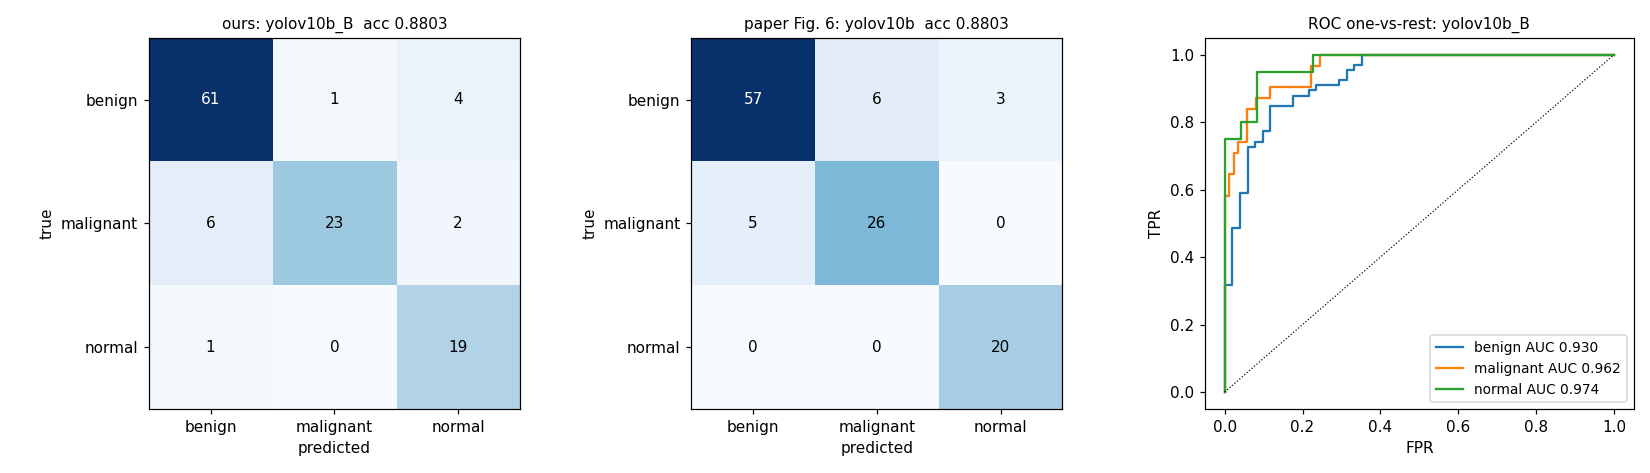

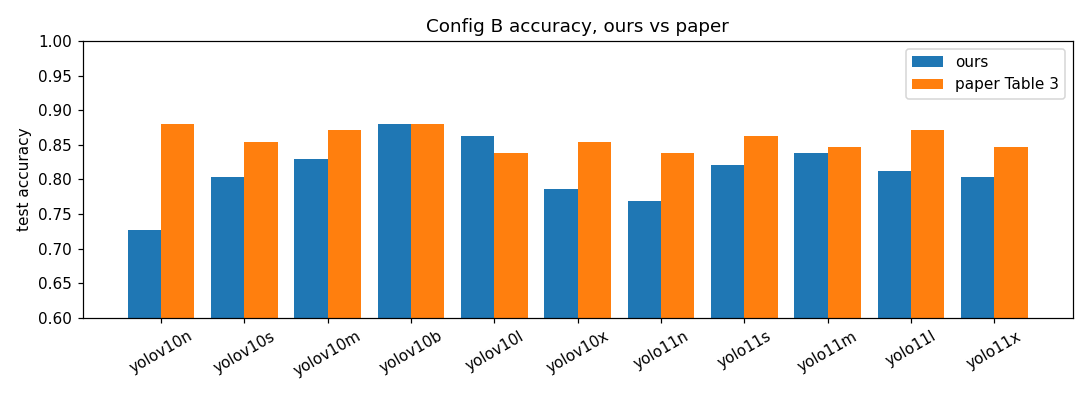

In [18]:
# ---------------- figures for the headline run (Fig. 5 ROC, Fig. 6 confusion) + all-variant accuracy bar
def roc(y_bin, s):
    o = np.argsort(-s); yb = y_bin[o]; P, N = yb.sum(), len(yb) - yb.sum()
    return np.r_[0, np.cumsum(1 - yb) / max(N, 1)], np.r_[0, np.cumsum(yb) / max(P, 1)]
head = next((t for t in ("yolov10b_B", "yolov10n_B", "yolo11n_B") if t in ALL), next(iter(ALL), None))
if head:
    r = ALL[head]["yolo"]; y, p, S = r["_arrays"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
    for k, (cm, title) in enumerate([(np.array(r["confusion"]), f"ours: {head}  acc {r['accuracy']:.4f}"), (np.array(PAPER["fig6_confusion"]), "paper Fig. 6: yolov10b  acc 0.8803")]):
        ax[k].imshow(cm, cmap="Blues"); ax[k].set_title(title, fontsize=10)
        ax[k].set_xticks(range(3), CLASSES); ax[k].set_yticks(range(3), CLASSES); ax[k].set_xlabel("predicted"); ax[k].set_ylabel("true")
        for i in range(3):
            for j in range(3): ax[k].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    for i, c in enumerate(CLASSES):
        fpr, tpr = roc((y == i).astype(int), S[:, i]); ax[2].plot(fpr, tpr, label=f"{c} AUC {r['auc'][c]:.3f}")
    ax[2].plot([0, 1], [0, 1], "k:", lw=0.8); ax[2].set_xlabel("FPR"); ax[2].set_ylabel("TPR"); ax[2].set_title(f"ROC one-vs-rest: {head}", fontsize=10); ax[2].legend(fontsize=9)
    plt.tight_layout(); plt.savefig(REPORT / "fig_confusion_roc.png", dpi=110); plt.close()
    display(IPImage(filename=str(REPORT / "fig_confusion_roc.png")))

have = [v for v in VARIANTS if f"{v}_B" in ALL]
if have:
    x = np.arange(len(have)); ours = [ALL[f"{v}_B"]["yolo"]["accuracy"] for v in have]; theirs = [PAPER["table3"][v]["acc"] for v in have]
    plt.figure(figsize=(max(6, 0.9 * len(have)), 3.6)); plt.bar(x - 0.2, ours, 0.4, label="ours"); plt.bar(x + 0.2, theirs, 0.4, label="paper Table 3")
    plt.xticks(x, have, rotation=30); plt.ylim(0.6, 1.0); plt.ylabel("test accuracy"); plt.legend(); plt.title("Config B accuracy, ours vs paper"); plt.tight_layout()
    plt.savefig(REPORT / "fig_table3_bars.png", dpi=110); plt.close(); display(IPImage(filename=str(REPORT / "fig_table3_bars.png")))

In [19]:
# ---------------- report + tidy up
strip = lambda r: None if r is None else {k: v for k, v in r.items() if not k.startswith("_")}
(REPORT / "all_metrics.json").write_text(json.dumps({t: dict(yolo=strip(m["yolo"]), fusion=strip(m["fusion"]), train=m["train"]) for t, m in ALL.items()}, indent=1))
report = "\n\n".join([
    f"# BUSI replication report ({'SMOKE' if SMOKE else 'full'})",
    f"{time.strftime('%Y-%m-%d %H:%M')} | {elapsed_min():.0f} min | ultralytics {ultralytics.__version__} | torch {torch.__version__} | "
    f"{', '.join(torch.cuda.get_device_name(i) for i in range(N_GPU)) or 'CPU'} | runs: {len(ALL)} ok, failed {failed}, not started {[j['tag'] for j in unscheduled]}",
    "Values are ours; `(delta)` = ours - paper.",
    "## Table 3 (Config B)\n\n" + T3, "## Table 4 (ablation)\n\n" + T4, "## Gates\n\n" + "\n".join(f"- {g}" for g in GATES),
    "## Leakage\n\n" + TL,
    f"## MedSAM section 4.3 (GT-box prompts) - fusion recipe: {RECIPE_NAME}\n\n{RECIPE_WHY}\n\n"
    + md_table([[c, s["n"], f"{s['dice']:.4f}", f"{PAPER['medsam_sec43'][c]['dice']:.4f}", f"{s['iou_true']:.4f}", f"{PAPER['medsam_sec43'][c]['iou']:.4f}", f"{s['iou_pred_head']:.4f}"] for c, s in summary.items()],
               ["class", "n", "Dice", "paper", "IoU true", "paper", "IoU pred-head"])
    + "\n\nPreprocessing sensitivity (mean Dice / true IoU over the same images):\n\n"
    + md_table([[n, f"{d.dice.mean():.4f}", f"{d.iou_true.mean():.4f}"] for n, d in SENS.items()], ["recipe", "Dice", "IoU"]),
])
(REPORT / "report.md").write_text(report)
print(report)

# full run: free the big regenerable folders so the saved output stays small (each is rebuilt in minutes).
# smoke run: keep them, so single cells can be re-run without rebuilding everything.
if not SMOKE:
    for d in (RUNS, WEIGHTS, CACHE, DATA): shutil.rmtree(d, ignore_errors=True)
print("\noutput:")
for d in (RESULTS, REPORT):
    print(f"  {d.name}/  {sum(p.stat().st_size for p in d.rglob('*') if p.is_file())/1e6:.0f} MB: " + ", ".join(sorted(p.name for p in d.iterdir())))

# BUSI replication report (full)

2026-09-16 05:38 | 578 min | ultralytics 8.3.40 | torch 2.10.0+cu128 | Tesla T4, Tesla T4 | runs: 14 ok, failed [], not started ['yolov10b_B_s7', 'yolov10b_B_s1337']

Values are ours; `(delta)` = ours - paper.

## Table 3 (Config B)

| Model    | Accuracy         | F1 macro         | F1 benign        | F1 malignant     | F1 normal        | test mAP50       | val mAP50 (vs T2) | epochs / time              |
|----------|------------------|------------------|------------------|------------------|------------------|------------------|-------------------|----------------------------|
| yolov10n | 0.7265 (-0.1538) | 0.7142 (-0.1571) | 0.7692 (-0.1428) | 0.6562 (-0.1620) | 0.7170 (-0.1667) | 0.5938 (-0.1892) | 0.5794 (-0.1747)  | 85 (best 55) / 30.5 min    |
| yolov10s | 0.8034 (-0.0513) | 0.7715 (-0.0724) | 0.8636 (-0.0235) | 0.7451 (-0.0486) | 0.7059 (-0.1452) | 0.7566 (-0.0372) | 0.7163 (-0.1099)  | 76 (best 46) / 33.6 min    |
| yolov10m | 0.8291 (-0.0427

### What to take away from the run

* `report/report.md` — the tables above; `report/all_metrics.json` — every number per run, including per-class precision/recall/F1 and AUC.
* `results/<run>/preds.json` and `preds_fused.json` — enough to recompute anything without a GPU.
* `results/manifest.csv`, `dedup_report.csv`, `leaky_test_stems.json` — which image went where, and which test images are contaminated.
* `results/medsam_standalone.json` — §4.3 per-image Dice / true IoU / predicted-IoU.

To finish runs the budget skipped: **Add Input → Your Work → this notebook**, set `SMOKE = False`, commit again.